In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
sns.set(style='whitegrid', context='notebook')

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


# DATA CLEANING

In [5]:
print(df.head())

   MolLogP    MolWt  NumRotatableBonds  AromaticProportion  logS
0   2.5954  167.850                0.0                 0.0 -2.18
1   2.3765  133.405                0.0                 0.0 -2.00
2   2.5938  167.850                1.0                 0.0 -1.74
3   2.0289  133.405                1.0                 0.0 -1.48
4   2.9189  187.375                1.0                 0.0 -3.04


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MolLogP             1144 non-null   float64
 1   MolWt               1144 non-null   float64
 2   NumRotatableBonds   1144 non-null   float64
 3   AromaticProportion  1144 non-null   float64
 4   logS                1144 non-null   float64
dtypes: float64(5)
memory usage: 44.8 KB


In [7]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
MolLogP               0
MolWt                 0
NumRotatableBonds     0
AromaticProportion    0
logS                  0
dtype: int64


In [8]:
df.fillna(df.median(), inplace=True)

# OUTLIER DETECTION

In [10]:
z_scores = np.abs(df.apply(zscore))
threshold = 3
df_cleaned = df[(z_scores < threshold).all(axis=1)]

# **UNIVARIATE ANALYSIS**

In [12]:
print(df.describe())

           MolLogP        MolWt  NumRotatableBonds  AromaticProportion  \
count  1144.000000  1144.000000        1144.000000         1144.000000   
mean      2.449133   204.631675           2.173951            0.364932   
std       1.866003   102.620500           2.627398            0.343305   
min      -7.571400    16.043000           0.000000            0.000000   
25%       1.414900   122.126000           0.000000            0.000000   
50%       2.340300   183.594500           1.000000            0.375000   
75%       3.406475   270.715750           3.000000            0.666667   
max      10.388600   780.949000          23.000000            1.000000   

              logS  
count  1144.000000  
mean     -3.057997  
std       2.096502  
min     -11.600000  
25%      -4.332250  
50%      -2.870500  
75%      -1.600000  
max       1.580000  


# Histograms for all numeric variables

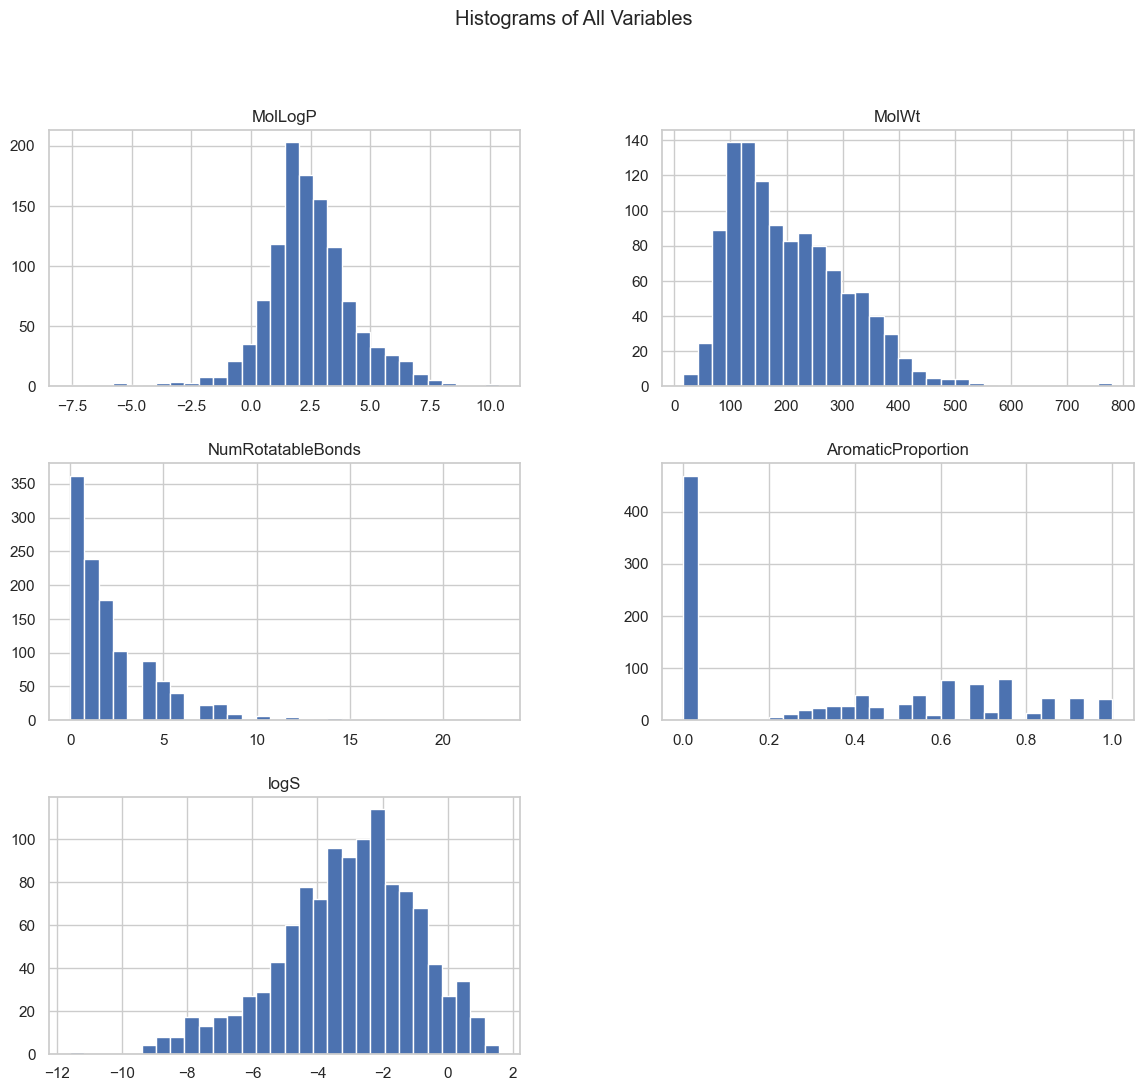

In [14]:
df.hist(figsize=(14, 12), bins=30)
plt.suptitle('Histograms of All Variables')
plt.show()

# Box plots

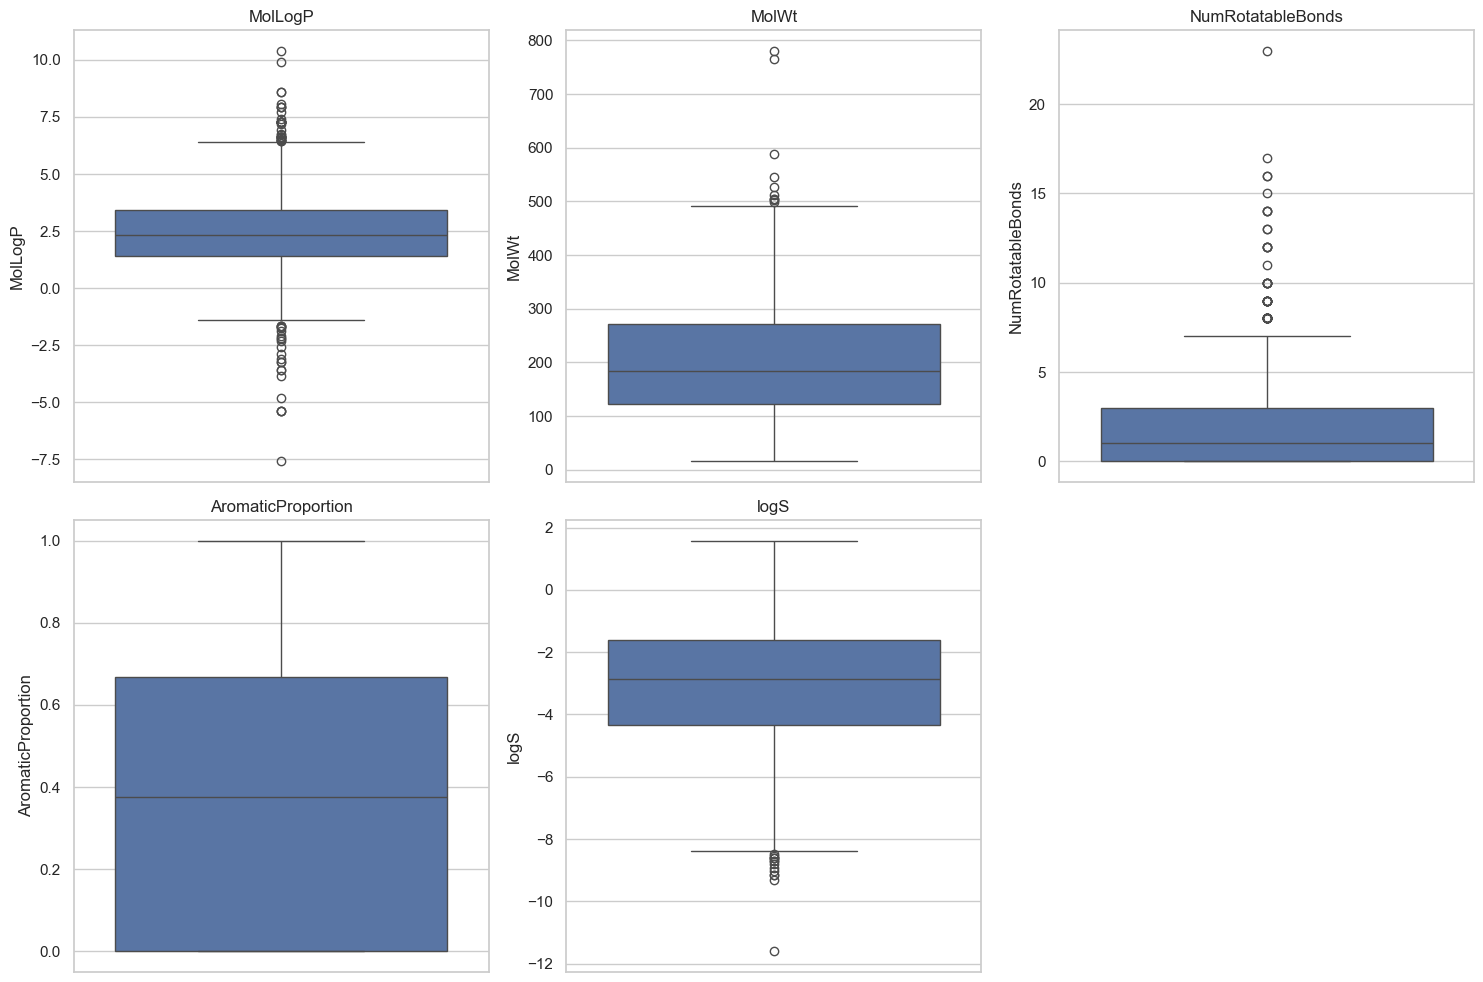

In [16]:
plt.figure(figsize=(15, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Violin plots

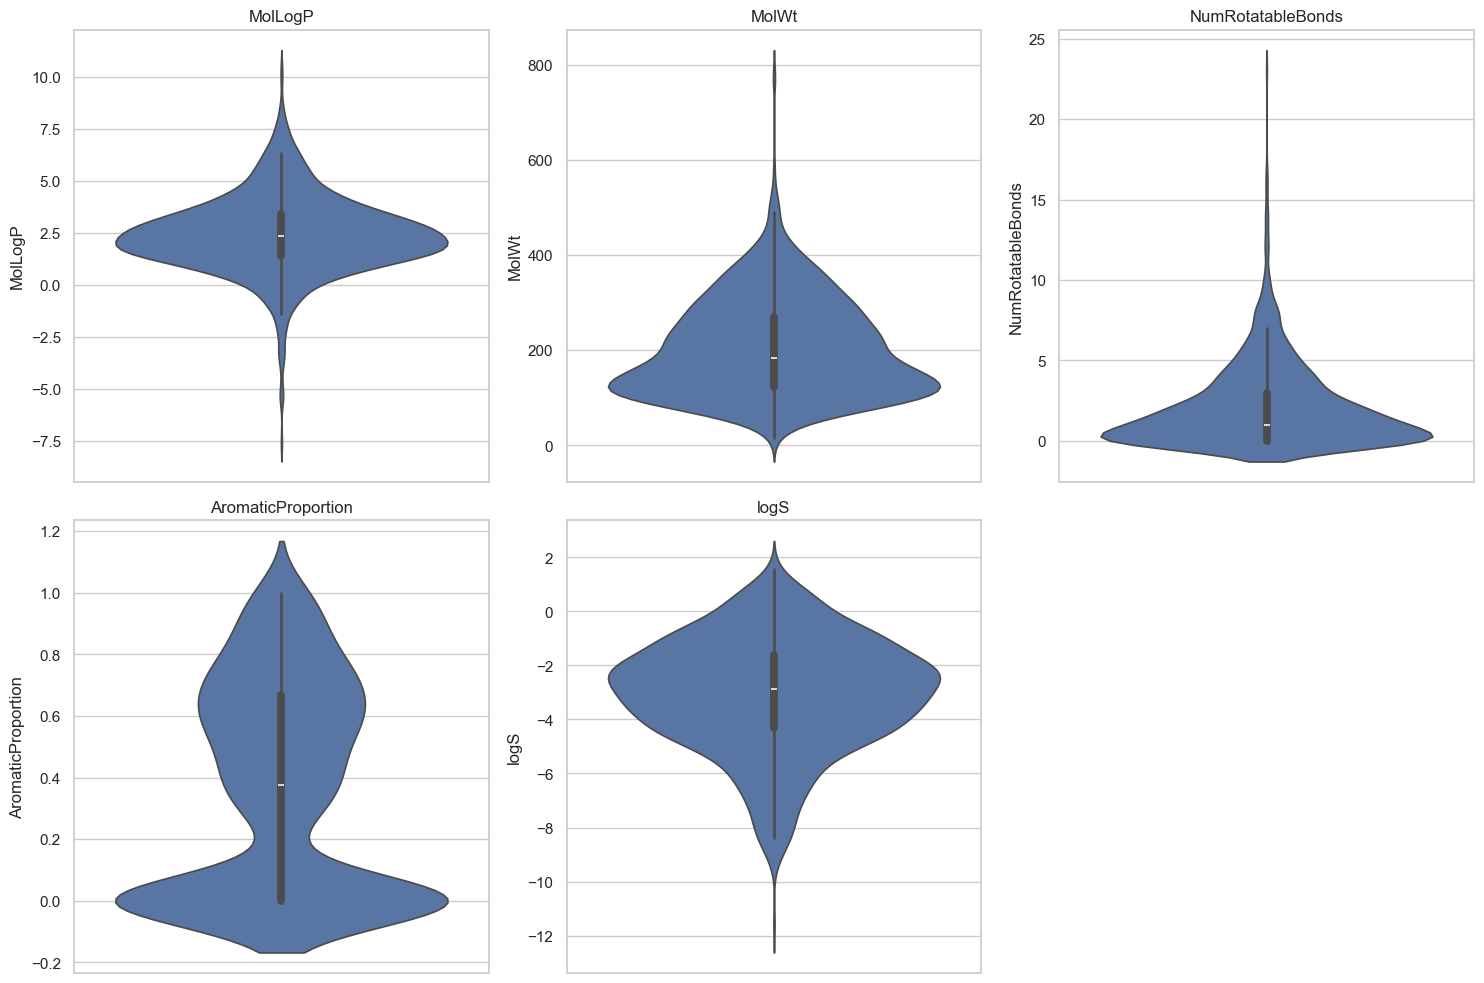

In [18]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.violinplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Skewness and Kurtosis

In [22]:
print("Skewness and Kurtosis:")
for col in numeric_cols:
    print(f'{col}: Skewness = {skew(df[col])}, Kurtosis = {kurtosis(df[col])}')

Skewness and Kurtosis:
MolLogP: Skewness = -0.01296513214694116, Kurtosis = 2.4881156615279796
MolWt: Skewness = 0.8893087911387616, Kurtosis = 1.2006569714187405
NumRotatableBonds: Skewness = 2.1553469325812156, Kurtosis = 7.4656953957553185
AromaticProportion: Skewness = 0.22600553751344823, Kurtosis = -1.413589090080197
logS: Skewness = -0.4839545835670128, Kurtosis = 0.16414203376299952


# Kernel Density Distribution

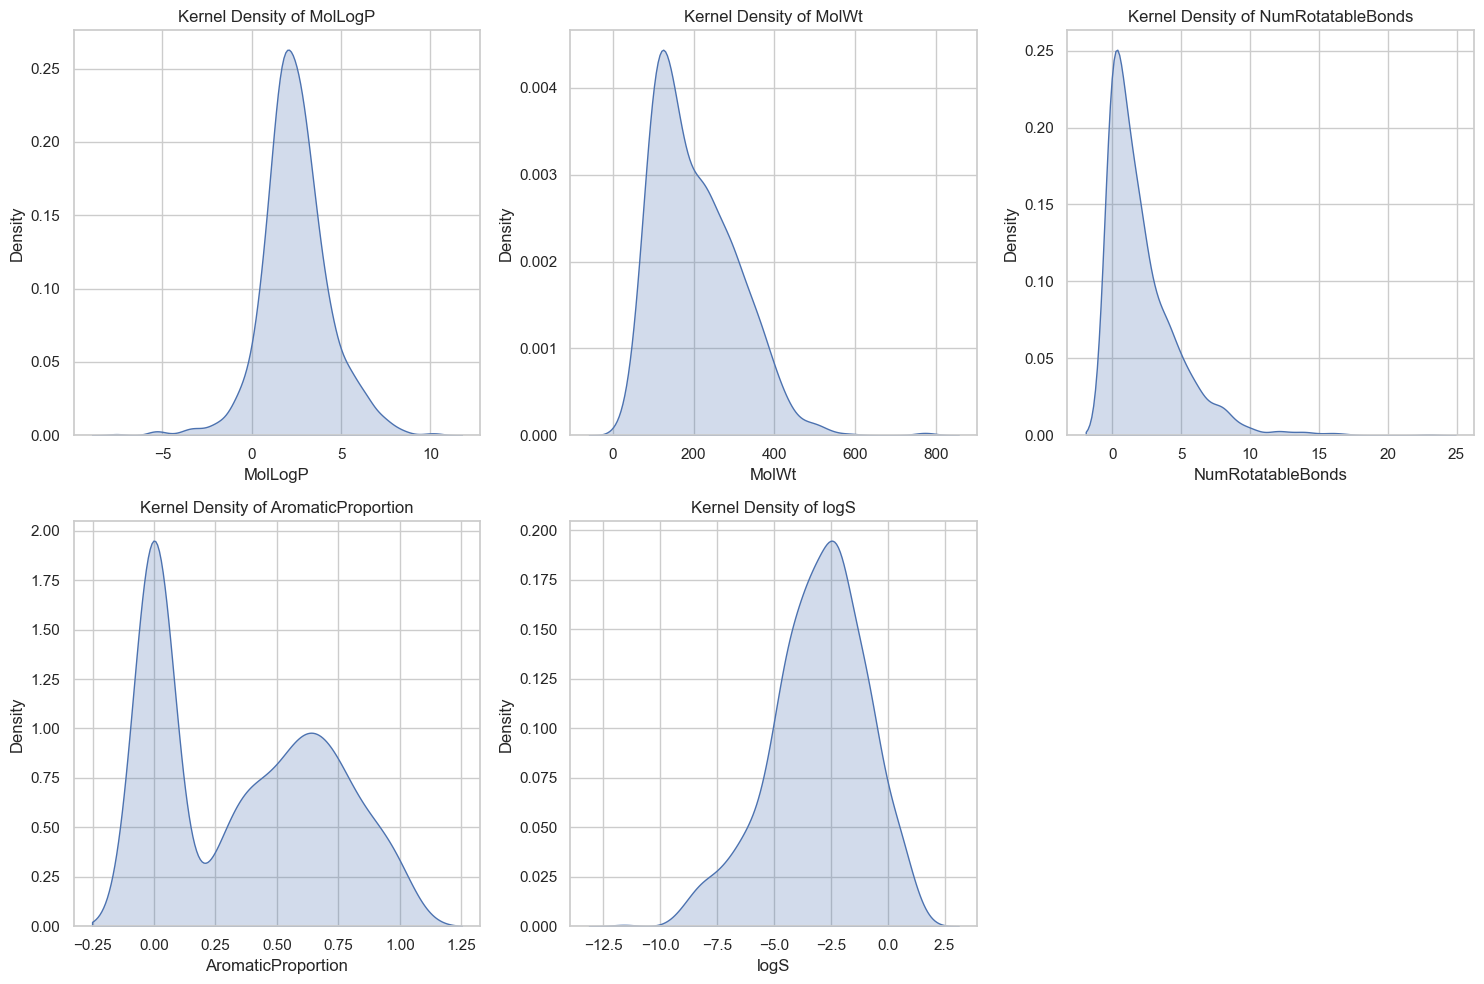

In [25]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Kernel Density of {col}')
plt.tight_layout()
plt.show()

# Data Distribution

#### Distribution Plots for Target Variable: Visualize the distribution of the target variable 'logS' using a histogram and a KDE plot to understand its distribution.

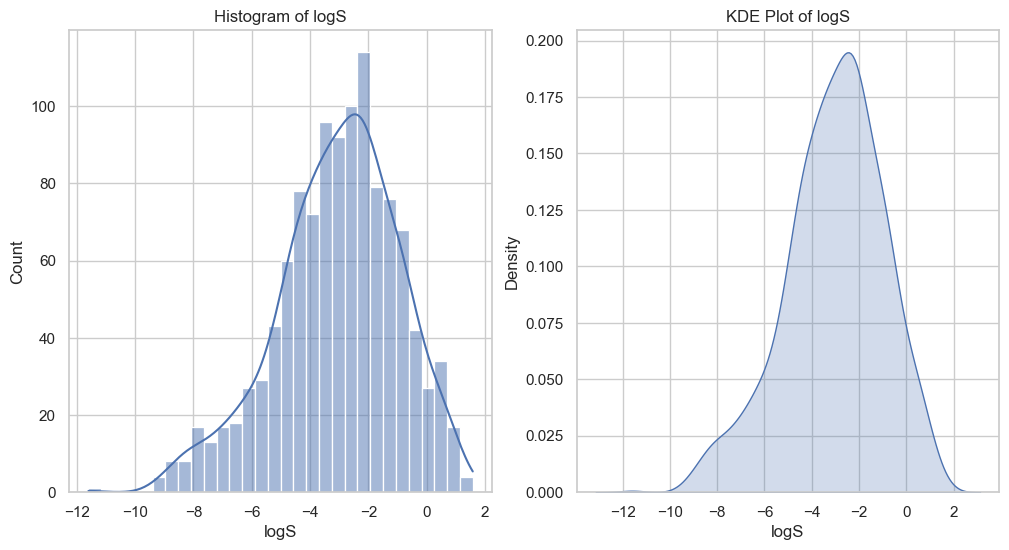

In [34]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['logS'], bins=30, kde=True)
plt.title('Histogram of logS')

plt.subplot(1, 2, 2)
sns.kdeplot(df['logS'], fill=True)
plt.title('KDE Plot of logS')
plt.show()

## Outliers Using IQR

In [36]:
print("Outliers using IQR:")
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum())

Outliers using IQR:
MolLogP               57
MolWt                 10
NumRotatableBonds     54
AromaticProportion     0
logS                  14
dtype: int64


# **Univariate Analysis Conclusion**

#### The dataset contains several variables with varying distributions. Skewness and kurtosis values indicate the presence of non-normal distributions, and box plots reveal outliers in some variables

#### Skewness and kurtosis values indicate the presence of non-normal distributions, and box plots reveal outliers in some variables.

# **MULTIVARIATE ANALYSIS**

In [42]:
corr = df.corr()

# HEATMAP

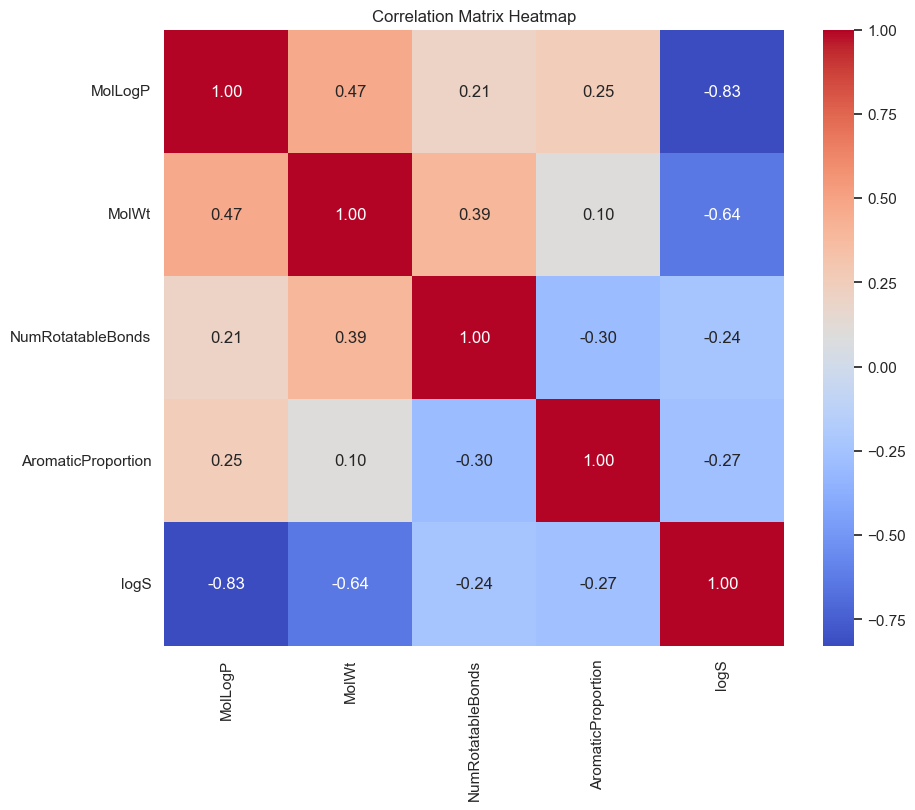

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# PAIR PLOT

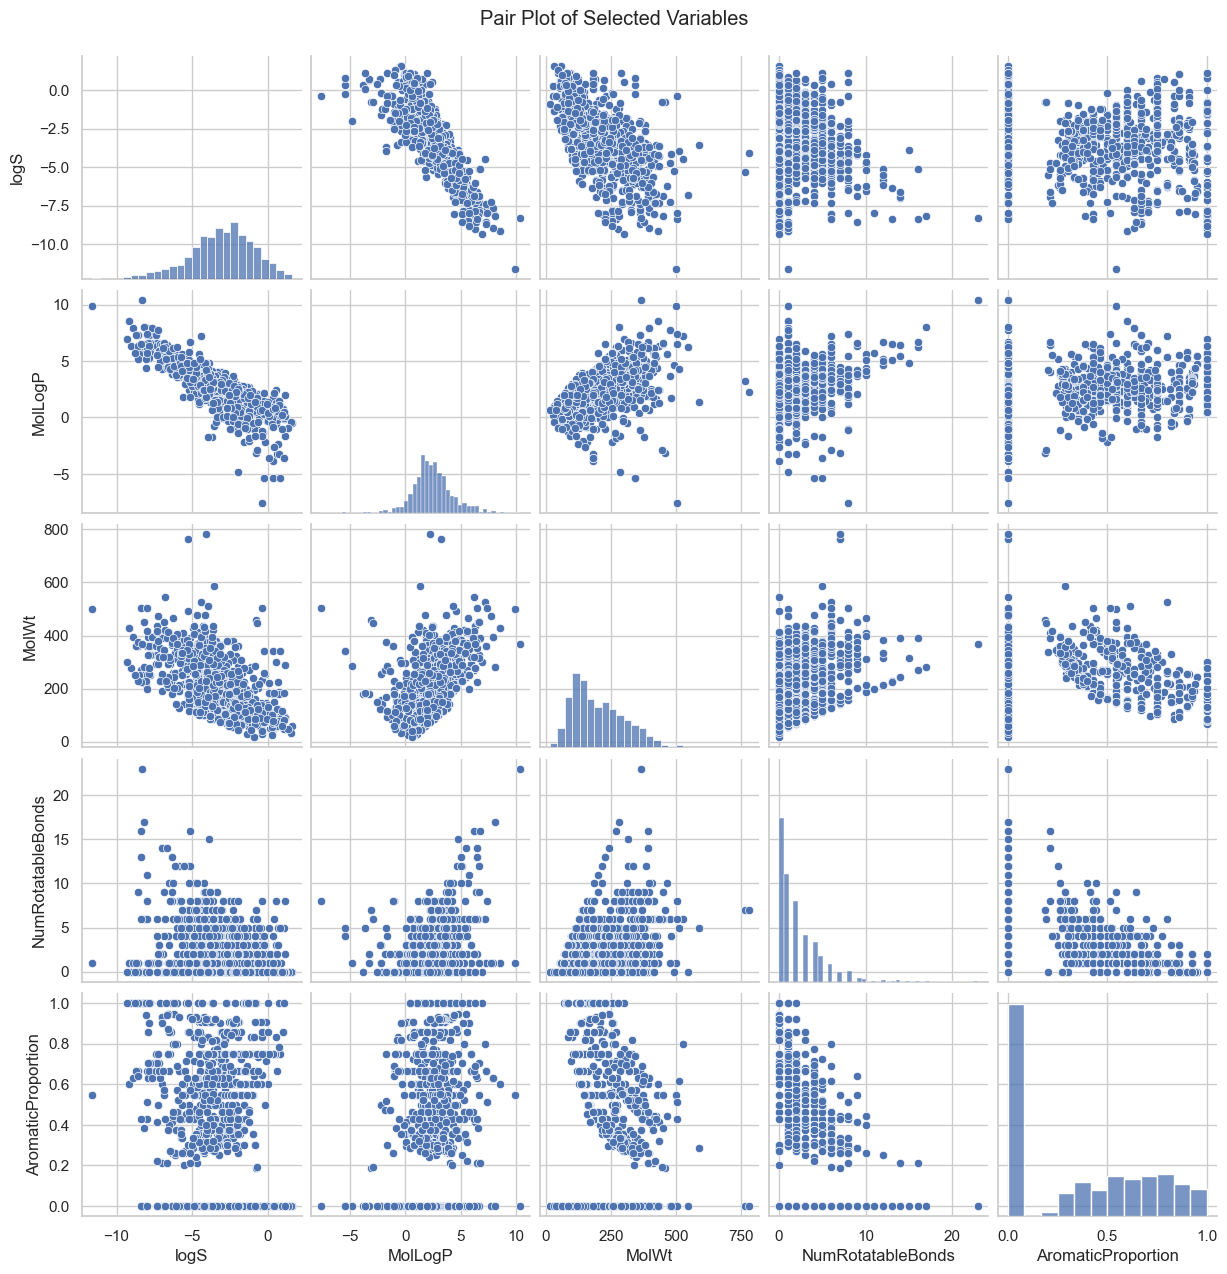

In [47]:
selected_columns = ['logS', 'MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion']
if all(col in df.columns for col in selected_columns):
    sns.pairplot(df[selected_columns])
    plt.suptitle('Pair Plot of Selected Variables', y=1.02)
    plt.show()
else:
    print('One or more selected columns are not available in the dataset.')

In [50]:
features = [col for col in df.columns if col != 'logS']

# SCATTER PLOT

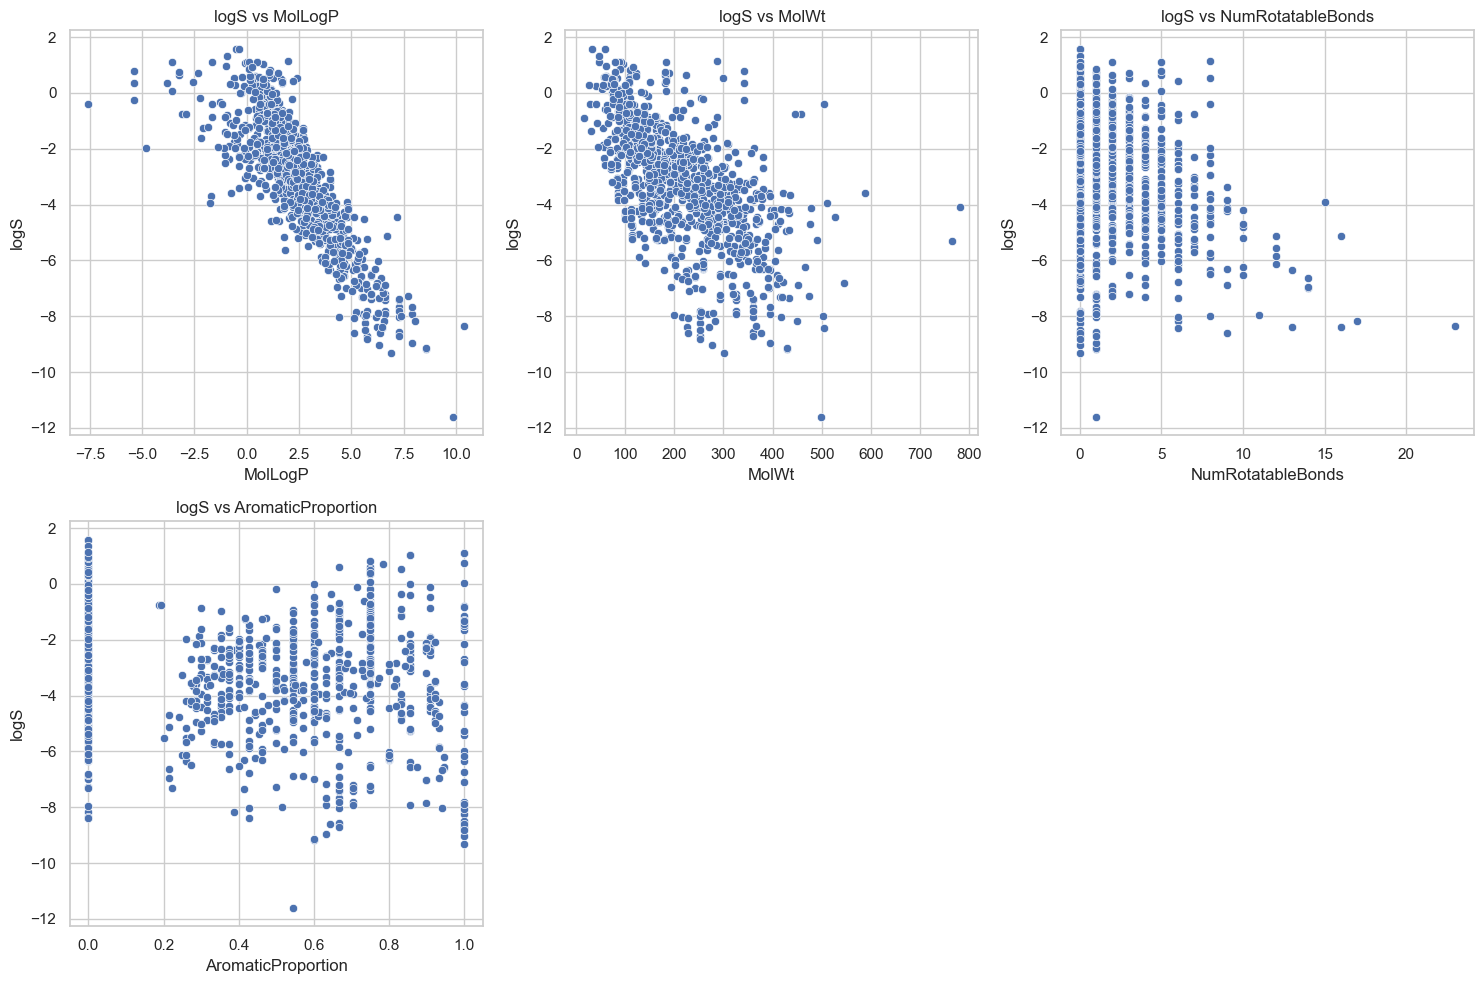

In [52]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feature], y=df['logS'])
    plt.xlabel(feature)
    plt.ylabel('logS')
    plt.title(f'logS vs {feature}')
plt.tight_layout()
plt.show()

# FACETED HISTOGRAM

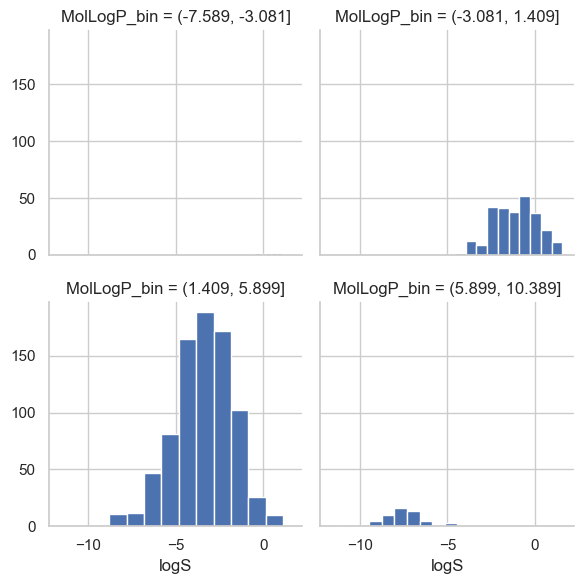

In [54]:
df['MolLogP_bin'] = pd.cut(df['MolLogP'], bins=4)
facet = sns.FacetGrid(df, col="MolLogP_bin", col_wrap=2, height=3, aspect=1)
facet.map(plt.hist, "logS")
plt.show()

# 3D SCATTER PLOT

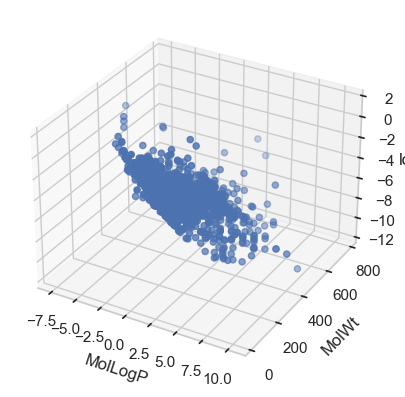

In [57]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['MolLogP'], df['MolWt'], df['logS'])
ax.set_xlabel('MolLogP')
ax.set_ylabel('MolWt')
ax.set_zlabel('logS')
plt.show()

# HYPOTHESIS TESTING

## T-Test

### T-test for Significant Differences: Perform a t-test to check for significant differences in 'logS' between different groups if any categorical variables exist

In [64]:
from scipy.stats import ttest_ind

group1 = df[df['MolLogP'] <= df['MolLogP'].median()]['logS']
group2 = df[df['MolLogP'] > df['MolLogP'].median()]['logS']

t_stat, p_value = ttest_ind(group1, group2)
print(f'T-test: t-statistic = {t_stat}, p-value = {p_value}')

T-test: t-statistic = 33.250858352239746, p-value = 4.171591538950977e-170


# **Multivariate Analysis Conclusion**

##### The multivariate analysis conducted on the dataset reveals several significant correlations that exist between specific molecular descriptors and the target variable, which is denoted as 'logS'. To gain a clearer understanding of these relationships, visual tools such as pair plots and scatter plots are utilized, as they effectively provide valuable insights into how these variables interact.

#####  Additionally, the correlation matrix serves as a useful instrument in this analysis, as it highlights the strength and nature of these associations, allowing for a more nuanced interpretation of the data. Given these findings, it would be prudent to proceed with further analysis, which may include developing predictive models that leverage these significant descriptors to enhance predictive accuracy and understanding of the underlying data dynamics.

# DATA PREPARATION

In [70]:
y = df_cleaned['logS']
x = df_cleaned.drop('logS', axis=1)

# SPILLTING DATA

In [72]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

# MODEL BUILDING (LINEAR REGRESSION)

In [74]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

# PREDICTION

In [76]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

## Evaluating Model Performance

In [78]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_lr_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_lr_test_pred))
r2 = r2_score(y_test, y_lr_test_pred)

In [79]:
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")
print(f"R-squared: {r2}")

Train RMSE: 0.9618622577403222
Test RMSE: 0.985693425937163
R-squared: 0.7560220994683533


## Coefficients Interpretation

In [81]:
coef_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': lr.coef_})
print("\nRegression Coefficients:")
print(coef_df)


Regression Coefficients:
              Feature  Coefficient
0             MolLogP    -0.807986
1               MolWt    -0.006531
2   NumRotatableBonds     0.018694
3  AromaticProportion    -0.372479


# **Linear Regression Visualization (Predicted vs Actual)**

# **Train Set Visualization**

Text(0.5, 1.0, 'Train Set: Actual vs Predicted')

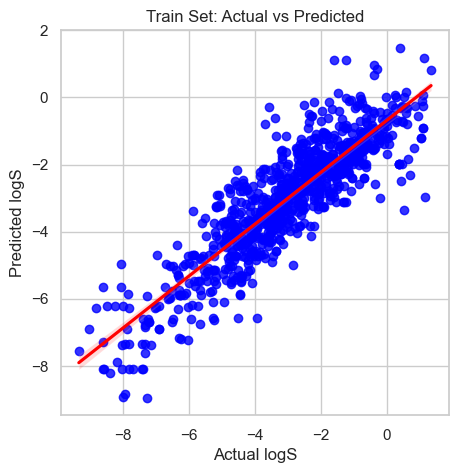

In [84]:
plt.figure(figsize=(5, 5))
sns.regplot(x=y_train, y=y_lr_train_pred, scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel("Actual logS")
plt.ylabel("Predicted logS")
plt.title("Train Set: Actual vs Predicted")

# **Test Set Visualization**

Text(0, 0.5, 'Experimental Logs')

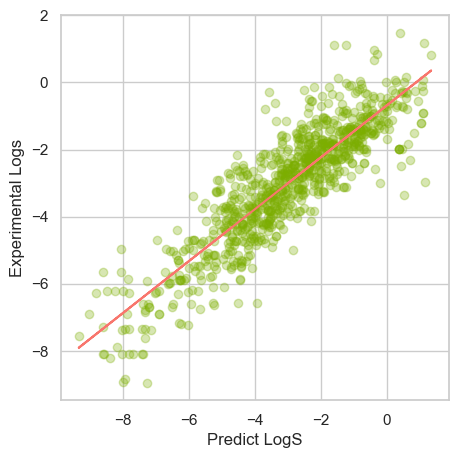

In [86]:
plt.figure(figsize=(5, 5))
plt.scatter(x=y_train,y=y_lr_train_pred,c="#7CAE00",alpha=0.3)

z=np.polyfit(y_train,y_lr_train_pred,1)
p = np.poly1d(z)
plt.plot(y_train,p(y_train),'#F8766D')

plt.xlabel('Predict LogS')
plt.ylabel('Experimental Logs')